In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
 
print("Libraries imported ✅")

Libraries imported ✅


In [3]:
PATH = 'C:/Users/Lenovo/Downloads/RestoDataset/foodDemand_train'
 
train  = pd.read_csv(PATH + '/train.csv')
center = pd.read_csv(PATH + '/fulfilment_center_info.csv')
meal   = pd.read_csv(PATH + '/meal_info.csv')
 
df = train.merge(center, on='center_id', how='left') \
          .merge(meal,   on='meal_id',   how='left')
 
# Sort by center, meal, week — required before lag features
df = df.sort_values(['center_id', 'meal_id', 'week']).reset_index(drop=True)
 
print(f"Dataset loaded & sorted: {df.shape}")

Dataset loaded & sorted: (456548, 15)


In [4]:
df['week_in_year']   = ((df['week'] - 1) % 52) + 1
df['month']          = ((df['week_in_year'] - 1) // 4) + 1
df['quarter']        = ((df['month'] - 1) // 3) + 1
df['is_weekend']     = (df['week_in_year'] % 2 == 0).astype(int)
df['is_holiday']     = ((df['week_in_year'] == 1) |
                        (df['week_in_year'] == 26) |
                        (df['week_in_year'] == 52)).astype(int)
 
print("\nChronological features added:")
print(df[['week', 'week_in_year', 'month', 'quarter',
          'is_weekend', 'is_holiday']].head(8))


Chronological features added:
   week  week_in_year  month  quarter  is_weekend  is_holiday
0     1             1      1        1           0           1
1     2             2      1        1           1           0
2     3             3      1        1           0           0
3     4             4      1        1           1           0
4     5             5      2        1           0           0
5     6             6      2        1           1           0
6     7             7      2        1           0           0
7     8             8      2        1           1           0


In [5]:
group = df.groupby(['center_id', 'meal_id'])['num_orders']
 
df['lag_1']  = group.shift(1)   # 1 week ago
df['lag_2']  = group.shift(2)   # 2 weeks ago
df['lag_4']  = group.shift(4)   # 4 weeks ago (1 month)
df['lag_8']  = group.shift(8)   # 8 weeks ago (2 months)
 
print("\nLag features added:")
print(df[['center_id', 'meal_id', 'week', 'num_orders',
          'lag_1', 'lag_2', 'lag_4', 'lag_8']].head(15))


Lag features added:
    center_id  meal_id  week  num_orders   lag_1   lag_2   lag_4   lag_8
0          10     1062     1         865     NaN     NaN     NaN     NaN
1          10     1062     2         782   865.0     NaN     NaN     NaN
2          10     1062     3         851   782.0   865.0     NaN     NaN
3          10     1062     4        1202   851.0   782.0     NaN     NaN
4          10     1062     5         958  1202.0   851.0   865.0     NaN
5          10     1062     6        1094   958.0  1202.0   782.0     NaN
6          10     1062     7        1513  1094.0   958.0   851.0     NaN
7          10     1062     8        1149  1513.0  1094.0  1202.0     NaN
8          10     1062     9        1282  1149.0  1513.0   958.0   865.0
9          10     1062    10        1473  1282.0  1149.0  1094.0   782.0
10         10     1062    11        1363  1473.0  1282.0  1513.0   851.0
11         10     1062    12        1295  1363.0  1473.0  1149.0  1202.0
12         10     1062    13  

In [6]:
group_roll = df.groupby(['center_id', 'meal_id'])['num_orders']
 
df['rolling_mean_4']  = group_roll.transform(
    lambda x: x.shift(1).rolling(4,  min_periods=1).mean()
)
df['rolling_mean_8']  = group_roll.transform(
    lambda x: x.shift(1).rolling(8,  min_periods=1).mean()
)
df['rolling_std_4']   = group_roll.transform(
    lambda x: x.shift(1).rolling(4,  min_periods=1).std()
)
 
print("\nRolling window features added:")
print(df[['week', 'num_orders', 'rolling_mean_4',
          'rolling_mean_8', 'rolling_std_4']].head(15))


Rolling window features added:
    week  num_orders  rolling_mean_4  rolling_mean_8  rolling_std_4
0      1         865             NaN             NaN            NaN
1      2         782      865.000000      865.000000            NaN
2      3         851      823.500000      823.500000      58.689863
3      4        1202      832.666667      832.666667      44.433471
4      5         958      925.000000      925.000000     188.196706
5      6        1094      948.250000      931.600000     184.011549
6      7        1513     1026.250000      958.666667     153.675795
7      8        1149     1191.750000     1037.857143     236.291310
8      9        1282     1178.500000     1051.750000     237.009845
9     10        1473     1259.500000     1103.875000     186.519883
10    11        1363     1354.250000     1190.250000     169.951709
11    12        1295     1316.750000     1254.250000     136.504884
12    13        1054     1353.250000     1265.875000      87.378010
13    14        

In [7]:
df = df.dropna(subset=['lag_1', 'lag_2', 'lag_4', 'lag_8'])
print(f"\nRows after dropping NaN: {len(df):,}")
 
# Sequential split — first 120 weeks train, last 25 weeks test
# NO random split — prevents data leakage from future into past
TRAIN_CUTOFF = 120
 
FEATURES = [
    'week', 'week_in_year', 'month', 'quarter', 'is_weekend', 'is_holiday',
    'checkout_price', 'base_price', 'emailer_for_promotion', 'homepage_featured',
    'center_id', 'meal_id', 'op_area',
    'lag_1', 'lag_2', 'lag_4', 'lag_8',
    'rolling_mean_4', 'rolling_mean_8', 'rolling_std_4'
]
TARGET = 'num_orders'
 
train_df = df[df['week'] <= TRAIN_CUTOFF]
test_df  = df[df['week'] >  TRAIN_CUTOFF]
 
X_train = train_df[FEATURES]
y_train = train_df[TARGET]
X_test  = test_df[FEATURES]
y_test  = test_df[TARGET]
 
print(f"\nSequential Train/Test Split:")
print(f"  Train : Week 1–{TRAIN_CUTOFF}   → {len(X_train):,} rows")
print(f"  Test  : Week {TRAIN_CUTOFF+1}–145 → {len(X_test):,} rows")


Rows after dropping NaN: 427,851

Sequential Train/Test Split:
  Train : Week 1–120   → 345,824 rows
  Test  : Week 121–145 → 82,027 rows


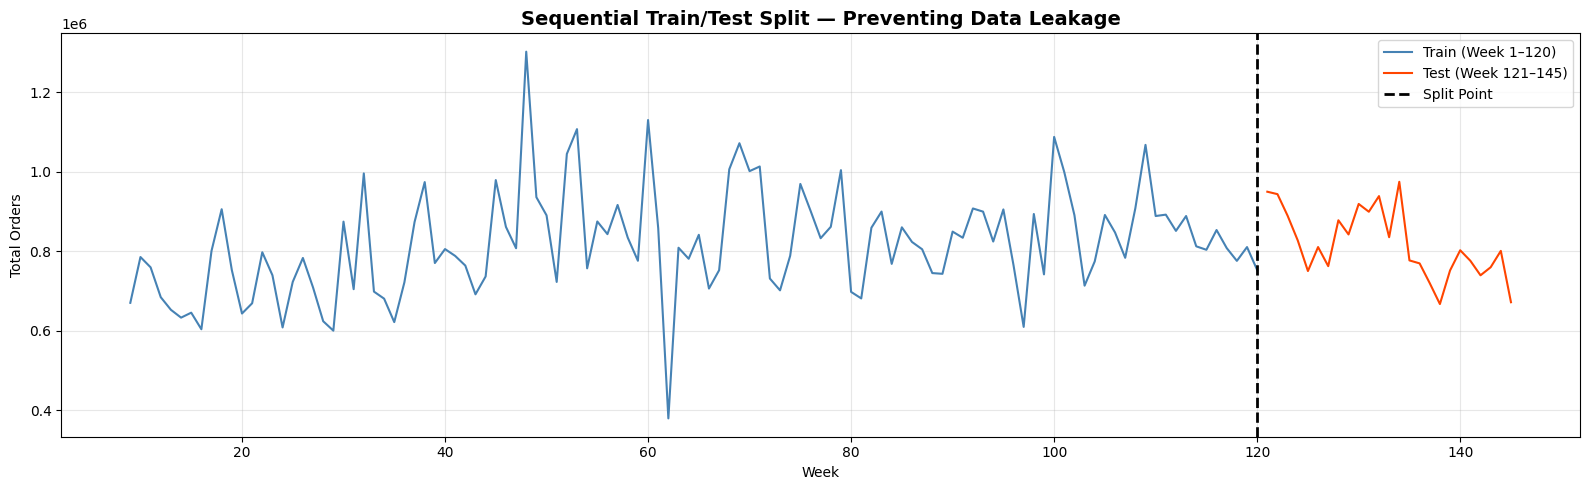

Saved: train_test_split.png ✅


In [8]:
weekly_train = train_df.groupby('week')[TARGET].sum()
weekly_test  = test_df.groupby('week')[TARGET].sum()
 
plt.figure(figsize=(16, 5))
plt.plot(weekly_train.index, weekly_train.values,
         color='steelblue', linewidth=1.5, label='Train (Week 1–120)')
plt.plot(weekly_test.index, weekly_test.values,
         color='orangered', linewidth=1.5, label='Test (Week 121–145)')
plt.axvline(x=TRAIN_CUTOFF, color='black', linestyle='--',
            linewidth=2, label='Split Point')
plt.title('Sequential Train/Test Split — Preventing Data Leakage',
          fontsize=14, fontweight='bold')
plt.xlabel('Week')
plt.ylabel('Total Orders')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('train_test_split.png', dpi=150)
plt.show()
print("Saved: train_test_split.png ✅")

In [9]:
X_train.to_csv('X_train.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
X_test.to_csv('X_test.csv',   index=False)
y_test.to_csv('y_test.csv',   index=False)
 
print("\n" + "=" * 50)
print("WEEK 2 COMPLETE — SUMMARY")
print("=" * 50)
print(f"  Chronological Features : week_in_year, month, quarter, is_weekend, is_holiday")
print(f"  Lag Features           : lag_1, lag_2, lag_4, lag_8")
print(f"  Rolling Features       : rolling_mean_4, rolling_mean_8, rolling_std_4")
print(f"  Total Features         : {len(FEATURES)}")
print(f"  Train Rows             : {len(X_train):,}")
print(f"  Test Rows              : {len(X_test):,}")


WEEK 2 COMPLETE — SUMMARY
  Chronological Features : week_in_year, month, quarter, is_weekend, is_holiday
  Lag Features           : lag_1, lag_2, lag_4, lag_8
  Rolling Features       : rolling_mean_4, rolling_mean_8, rolling_std_4
  Total Features         : 20
  Train Rows             : 345,824
  Test Rows              : 82,027
